In [1]:
import math
import numpy as np
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 40)

# ===================== CONFIG (edit here only) =====================
ORGS = ["ESKAPE", "GAST", "INTRA", "RESP"]

# display name -> output folder name. ADD NEW MODELS HERE.
MODELS = {
    "BepiPred":  "bepipred3",
    "DiscoTope": "discotope3",
    "ElliPro":   "ellipro",
    "GraphBepi": "graphbepi",
    "SEMAi":     "sema",
    "RoBep":      "robep",
    "BepiPred2.0": "bepipred2",
}
MODEL_LIST = list(MODELS)

PRED = Path("../outputs")   # residue-level indexed predictions
GT = Path("../iedb")        # IEDB ground truth

# residue indexed-CSV columns
COL_UNIPROT = "uniprot"
COL_RES = "res_index"
COL_SCORE = "score"
COL_YPRED = "y_pred"        # each model's native-cutoff binary call

# IEDB linear ground-truth columns
GT_ID = "iedb_id"
GT_UNI = "uniprot_accession"
GT_START = "start_pos"
GT_END = "end_pos"

TAUS = np.linspace(0.0, 1.0, 101)   # detection-rate sweep grid
DET_POINTS = [0.25, 0.50, 0.75]     # illustrative operating points

# spatial-tolerance config (linear regional)
STRUCTURE_BASE = Path("../structures")  # AlphaFold PDBs: STRUCTURE_BASE/{org}/linear/{uniprot}.pdb  -- SET TO YOUR ROOT
D_ANGSTROM = 8.0                    # spatial gate, Cb-Cb (Ca for Gly)
K_VALUES = [0, 1, 2, 3]             # sequence-tolerance sweep
N_PERM = 20                        # permutations for the random-null baseline (lower for speed)
# ==================================================================


In [2]:
res_dfs, skipped = [], []
for name, folder in MODELS.items():
    for org in ORGS:
        path = PRED / folder / org / "linear" / f"{folder}_indexed.csv"
        if not path.exists():
            skipped.append((name, org))
            continue
        df = pd.read_csv(path)[[COL_UNIPROT, COL_RES, COL_SCORE, COL_YPRED]].copy()
        df.columns = ["uniprot", "res_index", "score", "y_pred"]
        df["uniprot"] = df["uniprot"].astype(str).str.strip()
        df["model"] = name
        df["organism"] = org
        res_dfs.append(df)

res = pd.concat(res_dfs, ignore_index=True)
print("residue rows:", res.shape)
if skipped:
    print("Missing (model, org):", skipped)


residue rows: (1028839, 6)


In [3]:
def load_epitopes(org):
    g = pd.read_csv(GT / org / "linear" / "linear_ground_truth.csv")
    out = pd.DataFrame({
        "uniprot": g[GT_UNI].astype(str).str.strip(),
        "start": g[GT_START].astype(int),
        "end": g[GT_END].astype(int),
    })
    out["iedb_id"] = g[GT_ID] if GT_ID in g.columns else np.arange(len(g))
    out["organism"] = org
    return out

epitopes = pd.concat([load_epitopes(o) for o in ORGS], ignore_index=True)
epitopes["epitope_length"] = epitopes["end"] - epitopes["start"] + 1
print("epitopes:", epitopes.shape)

# residue-level y_true = membership in any epitope span (model-independent)
true_res = set()
for e in epitopes.itertuples():
    for r in range(e.start, e.end + 1):
        true_res.add((e.uniprot, r))
res["y_true"] = [(u, r) in true_res for u, r in zip(res["uniprot"], res["res_index"])]
res["y_true"] = res["y_true"].astype(int)
print("residue prevalence (pooled):", round(res["y_true"].mean(), 4))


epitopes: (2920, 6)
residue prevalence (pooled): 0.1413


In [4]:
# duplicate residues per (model, protein)
dups = res.duplicated(["model", "uniprot", "res_index"]).sum()
print("duplicate (model,uniprot,res_index) rows:", dups)

cov = (res.groupby("model")
       .agg(proteins=("uniprot", "nunique"),
            residues=("res_index", "size"),
            positives=("y_true", "sum"))
       .reset_index())
cov["prevalence"] = (cov["positives"] / cov["residues"]).round(4)
print(cov.to_string(index=False))

# score-orientation check
print("\nScore-orientation (pooled positive-class mean score should exceed negative-class):")
for m, sub in res.groupby("model"):
    pos = sub.loc[sub.y_true == 1, "score"].mean()
    neg = sub.loc[sub.y_true == 0, "score"].mean()
    flag = "   <-- CHECK ORIENTATION" if pos < neg else ""
    print(f"  {m:10s} mean(score|pos)={pos:.3f}  mean(score|neg)={neg:.3f}{flag}")


duplicate (model,uniprot,res_index) rows: 0
      model  proteins  residues  positives  prevalence
   BepiPred       350    161721      21556      0.1333
BepiPred2.0       350    161731      21558      0.1333
  DiscoTope       337    146404      20675      0.1412
    ElliPro       337    146404      20675      0.1412
  GraphBepi       320    119771      19533      0.1631
      RoBep       337    146404      20675      0.1412
      SEMAi       337    146404      20675      0.1412

Score-orientation (pooled positive-class mean score should exceed negative-class):
  BepiPred   mean(score|pos)=0.099  mean(score|neg)=0.057
  BepiPred2.0 mean(score|pos)=0.528  mean(score|neg)=0.525
  DiscoTope  mean(score|pos)=0.224  mean(score|neg)=0.174
  ElliPro    mean(score|pos)=0.508  mean(score|neg)=0.487
  GraphBepi  mean(score|pos)=0.122  mean(score|neg)=0.104
  RoBep      mean(score|pos)=0.081  mean(score|neg)=0.048
  SEMAi      mean(score|pos)=0.632  mean(score|neg)=0.555


In [5]:
prot_sets = [set(res.loc[res.model == m, "uniprot"].unique()) for m in MODEL_LIST]
common_prot = set.intersection(*prot_sets)

res_fair = res[res["uniprot"].isin(common_prot)].copy()
epitopes_fair = epitopes[epitopes["uniprot"].isin(common_prot)].copy()

print("common proteins:", len(common_prot))
print("epitopes in fair subset:", len(epitopes_fair))
print(res_fair.groupby("model").size())


common proteins: 319
epitopes in fair subset: 2754
model
BepiPred       119464
BepiPred2.0    119474
DiscoTope      119474
ElliPro        119474
GraphBepi      119474
RoBep          119474
SEMAi          119474
dtype: int64


## 5. Operating points

`y_pred` = native cutoff (reference). `y_pred_matched` = prevalence-matched top-N per protein
(fair). Recall and precision are reported at both.

In [6]:
def add_matched_budget(df):
    # per (model, protein): top-N residues by score positive, N = true-residue count
    df = df.copy()
    df["y_pred_matched"] = 0
    for _, sub in df.groupby(["model", "uniprot"]):
        n_true = int(sub["y_true"].sum())
        if n_true > 0:
            idx = sub.sort_values("score", ascending=False).head(n_true).index
            df.loc[idx, "y_pred_matched"] = 1
    return df

res_fair = add_matched_budget(res_fair)
print("matched-budget positives per model:")
print(res_fair.groupby("model")["y_pred_matched"].sum())


matched-budget positives per model:
model
BepiPred       19531
BepiPred2.0    19533
DiscoTope      19533
ElliPro        19533
GraphBepi      19533
RoBep          19533
SEMAi          19533
Name: y_pred_matched, dtype: int64


In [7]:
def epitope_recall(res_df, epi_df, pred_col):
    scored = res_df.groupby(["model", "uniprot"])["res_index"].apply(set).to_dict()
    pos = (res_df[res_df[pred_col] == 1]
           .groupby(["model", "uniprot"])["res_index"].apply(set).to_dict())
    rows = []
    for m in MODEL_LIST:
        for e in epi_df.itertuples():
            rng = set(range(e.start, e.end + 1))
            sc = scored.get((m, e.uniprot), set())
            es = rng & sc
            if not es:
                rec = np.nan
            else:
                rec = len(es & pos.get((m, e.uniprot), set())) / len(es)
            rows.append({"model": m, "organism": e.organism, "uniprot": e.uniprot,
                         "iedb_id": e.iedb_id, "epitope_length": len(rng),
                         "scored_residues": len(es), "recall": rec})
    return pd.DataFrame(rows)

rec_native = epitope_recall(res_fair, epitopes_fair, "y_pred")
rec_matched = epitope_recall(res_fair, epitopes_fair, "y_pred_matched")

ep_recall = rec_native.rename(columns={"recall": "recall_native"})
ep_recall["recall_matched"] = rec_matched["recall"].values
print("per-epitope recall table:", ep_recall.shape)
print(ep_recall.head().round(3).to_string(index=False))


per-epitope recall table: (19278, 8)
   model organism uniprot  iedb_id  epitope_length  scored_residues  recall_native  recall_matched
BepiPred   ESKAPE  P11439      121              20               20            0.0           0.750
BepiPred   ESKAPE  P04739      571              17               17            0.0           1.000
BepiPred   ESKAPE  P11439      868              16               16            0.0           0.000
BepiPred   ESKAPE  P13794      953              11               11            0.0           0.727
BepiPred   ESKAPE  P13794     2040               7                7            0.0           0.571


In [8]:
def parse_cb_coords(pdb_file):
    # one representative coord per residue: CB, or CA for glycine
    coords = {}
    with open(pdb_file) as fh:
        for line in fh:
            if not line.startswith("ATOM"):
                continue
            atom = line[12:16].strip()
            resname = line[17:20].strip()
            if atom == "CB" or (atom == "CA" and resname == "GLY"):
                resi = int(line[22:26])
                coords[resi] = (float(line[30:38]), float(line[38:46]), float(line[46:54]))
    return coords

COORDS = {}
missing_pdb = []
pairs = epitopes_fair[["organism", "uniprot"]].drop_duplicates()
for org, uni in pairs.itertuples(index=False):
    pdb_file = STRUCTURE_BASE / org / "linear" / f"{uni}.pdb"
    if not pdb_file.exists():
        missing_pdb.append((org, uni))
        continue
    COORDS[(org, uni)] = parse_cb_coords(pdb_file)

print("proteins with coordinates:", len(COORDS))
if missing_pdb:
    print("missing PDBs:", len(missing_pdb), "e.g.", missing_pdb[:5])


proteins with coordinates: 319


Mean per-epitope recall vs sequence tolerance k (matched budget, d=8.0 A):
k                0      1      2      3
model                                  
BepiPred     0.689  0.721  0.742  0.751
BepiPred2.0  0.654  0.691  0.717  0.729
DiscoTope    0.660  0.771  0.805  0.815
ElliPro      0.665  0.718  0.739  0.746
GraphBepi    0.668  0.785  0.817  0.826
RoBep        0.657  0.703  0.721  0.728
SEMAi        0.666  0.752  0.778  0.787

k=0 vs Section-6 exact recall (should match):
  BepiPred   k0=0.689  exact=0.689
  DiscoTope  k0=0.660  exact=0.660
  ElliPro    k0=0.665  exact=0.665
  GraphBepi  k0=0.668  exact=0.668
  SEMAi      k0=0.666  exact=0.666
  RoBep      k0=0.657  exact=0.657
  BepiPred2.0 k0=0.654  exact=0.654


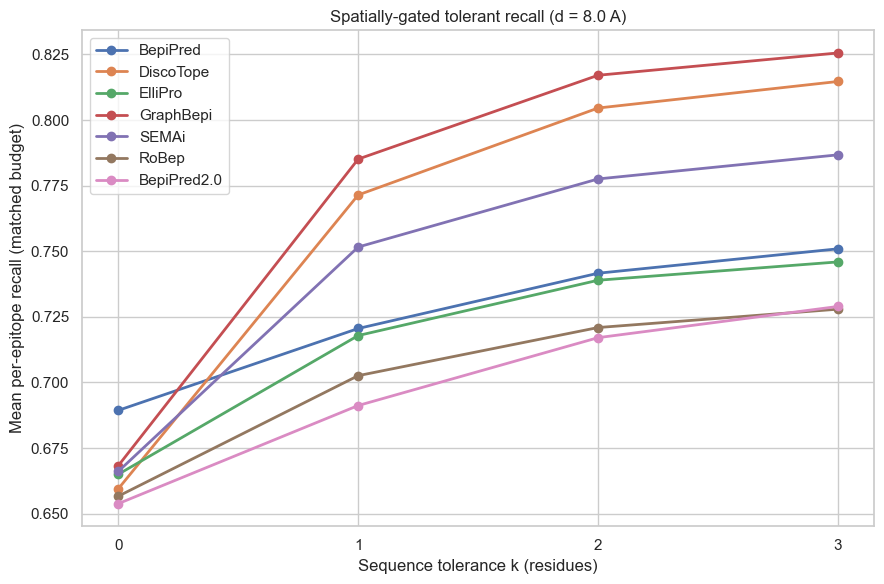

In [9]:
def tolerant_epitope_recall(res_df, epi_df, coords, pred_col, k, d):
    scored = res_df.groupby(["model", "uniprot"])["res_index"].apply(set).to_dict()
    pos = (res_df[res_df[pred_col] == 1]
           .groupby(["model", "uniprot"])["res_index"].apply(set).to_dict())
    rows = []
    for m in MODEL_LIST:
        for e in epi_df.itertuples():
            key = (m, e.uniprot)
            sc = scored.get(key, set())
            rng = [r for r in range(e.start, e.end + 1) if r in sc]
            if not rng:
                continue  # out of range for this model
            p = pos.get(key, set())
            cmap = coords.get((e.organism, e.uniprot), {})
            recovered = 0
            for r in rng:
                hit = False
                for cand in range(r - k, r + k + 1):
                    if cand not in p:
                        continue
                    if cand == r:                      # exact match, no gate needed
                        hit = True
                        break
                    if r in cmap and cand in cmap and math.dist(cmap[r], cmap[cand]) <= d:
                        hit = True
                        break
                recovered += int(hit)
            rows.append({"model": m, "organism": e.organism, "uniprot": e.uniprot,
                         "iedb_id": e.iedb_id, "k": k, "recall": recovered / len(rng)})
    return pd.DataFrame(rows)

sweep = pd.concat(
    [tolerant_epitope_recall(res_fair, epitopes_fair, COORDS, "y_pred_matched", k, D_ANGSTROM)
     for k in K_VALUES],
    ignore_index=True)

sweep_summary = (sweep.groupby(["model", "k"])["recall"].mean()
                 .reset_index().pivot(index="model", columns="k", values="recall"))
print(f"Mean per-epitope recall vs sequence tolerance k (matched budget, d={D_ANGSTROM} A):")
print(sweep_summary.round(3).to_string())

# consistency: k=0 must equal exact-match matched recall from Section 6
chk = (ep_recall.dropna(subset=["recall_matched"]).groupby("model")["recall_matched"].mean())
print("\nk=0 vs Section-6 exact recall (should match):")
for m in MODEL_LIST:
    print(f"  {m:10s} k0={sweep_summary.loc[m, 0]:.3f}  exact={chk[m]:.3f}")

plt.figure(figsize=(9, 6))
for m in MODEL_LIST:
    plt.plot(K_VALUES, [sweep_summary.loc[m, k] for k in K_VALUES], marker="o", lw=2, label=m)
plt.xlabel("Sequence tolerance k (residues)")
plt.ylabel("Mean per-epitope recall (matched budget)")
plt.title(f"Spatially-gated tolerant recall (d = {D_ANGSTROM} A)")
plt.xticks(K_VALUES)
plt.legend()
plt.tight_layout()
plt.show()


### 6d. Random baseline — is the tolerance gain real?

Tolerance inflates recall for any predictor: allowing ±k credit means even randomly placed
guesses sit near some epitope residues, increasingly so as k grows. So a high tolerant recall is
ambiguous — real localisation, or just guesses at a given density with tolerance scooping up
near-misses. The null strips the epitope signal but keeps everything else: per protein, randomly
pick N residues positive (N = matched budget; equivalent to shuffling scores within the protein),
keeping structure, epitopes, gate and tolerance fixed. Averaged over `N_PERM` permutations this is
the recall tolerance grants with **no skill**. The diagnostic is **gain above null = actual − null**:
if the structure models keep a larger gain than BepiPred at k ≥ 1, the inversion is real
region-localisation; if the gains converge, it was tolerance mechanics. The z-score is how many
null SDs the actual sits above the null mean.

*Caveat:* shuffling also removes spatial clustering, so gain-above-null credits real signal together
with prediction spatial-coherence; it does not separately isolate generic surface bias.

Tolerant recall vs random null (N_PERM=20, d=8.0 A):
      model  k  actual  null_mean  null_sd  gain_above_null       z
   BepiPred  0   0.689      0.645    0.002            0.044  17.848
   BepiPred  1   0.721      0.800    0.004           -0.079 -22.252
   BepiPred  2   0.742      0.849    0.004           -0.108 -30.162
   BepiPred  3   0.751      0.865    0.004           -0.114 -31.554
BepiPred2.0  0   0.654      0.645    0.002            0.009   4.686
BepiPred2.0  1   0.691      0.800    0.003           -0.109 -37.502
BepiPred2.0  2   0.717      0.849    0.004           -0.132 -36.412
BepiPred2.0  3   0.729      0.865    0.004           -0.136 -36.828
  DiscoTope  0   0.660      0.645    0.002            0.015   6.785
  DiscoTope  1   0.771      0.800    0.004           -0.028  -7.805
  DiscoTope  2   0.805      0.848    0.005           -0.044  -8.673
  DiscoTope  3   0.815      0.864    0.005           -0.050  -9.209
    ElliPro  0   0.665      0.646    0.002            0.019   7

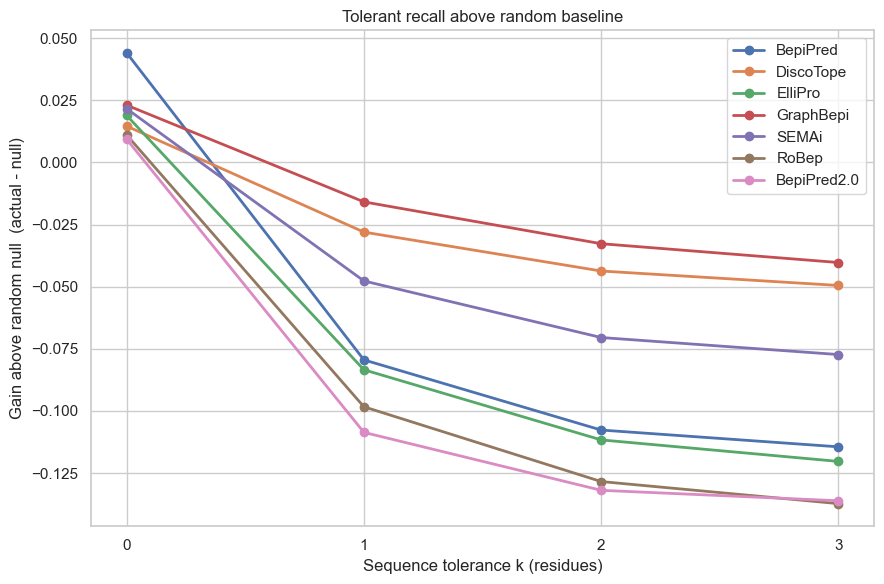

In [10]:
def random_matched_pred(res_df, rng):
    # per (model, protein): pick N random scored residues positive, N = true count
    df = res_df.copy()
    df["y_pred_random"] = 0
    for _, sub in df.groupby(["model", "uniprot"]):
        n = int(sub["y_true"].sum())
        if n > 0:
            pick = rng.choice(sub.index.values, size=min(n, len(sub)), replace=False)
            df.loc[pick, "y_pred_random"] = 1
    return df

null_rows = []
for b in range(N_PERM):
    rng_b = np.random.default_rng(1000 + b)
    rnd = random_matched_pred(res_fair, rng_b)
    for k in K_VALUES:
        t = tolerant_epitope_recall(rnd, epitopes_fair, COORDS, "y_pred_random", k, D_ANGSTROM)
        g = t.groupby("model")["recall"].mean()
        for m in MODEL_LIST:
            null_rows.append({"perm": b, "model": m, "k": k, "recall": g[m]})
null_df = pd.DataFrame(null_rows)

null_stats = (null_df.groupby(["model", "k"])["recall"]
              .agg(null_mean="mean", null_sd="std").reset_index())
actual = (sweep.groupby(["model", "k"])["recall"].mean()
          .reset_index().rename(columns={"recall": "actual"}))

comp = actual.merge(null_stats, on=["model", "k"])
comp["gain_above_null"] = comp["actual"] - comp["null_mean"]
comp["z"] = (comp["actual"] - comp["null_mean"]) / comp["null_sd"].replace(0, np.nan)

print(f"Tolerant recall vs random null (N_PERM={N_PERM}, d={D_ANGSTROM} A):")
print(comp.round(3).to_string(index=False))

plt.figure(figsize=(9, 6))
for m in MODEL_LIST:
    s = comp[comp.model == m].sort_values("k")
    plt.plot(s["k"], s["gain_above_null"], marker="o", lw=2, label=m)
plt.xlabel("Sequence tolerance k (residues)")
plt.ylabel("Gain above random null  (actual - null)")
plt.title("Tolerant recall above random baseline")
plt.xticks(K_VALUES)
plt.legend()
plt.tight_layout()
plt.show()


    Predictor  Sequence tolerance  Observed recall  Random-selection recall  Observed − random
 BepiPred-2.0                   0            0.654                    0.645              0.009
 BepiPred-3.0                   0            0.689                    0.645              0.044
DiscoTope-3.0                   0            0.660                    0.645              0.015
      ElliPro                   0            0.665                    0.646              0.019
    GraphBepi                   0            0.668                    0.645              0.023
        RoBep                   0            0.657                    0.646              0.011
      SEMA-3D                   0            0.666                    0.645              0.022
 BepiPred-2.0                   1            0.691                    0.800             -0.109
 BepiPred-3.0                   1            0.721                    0.800             -0.079
DiscoTope-3.0                   1            0.771

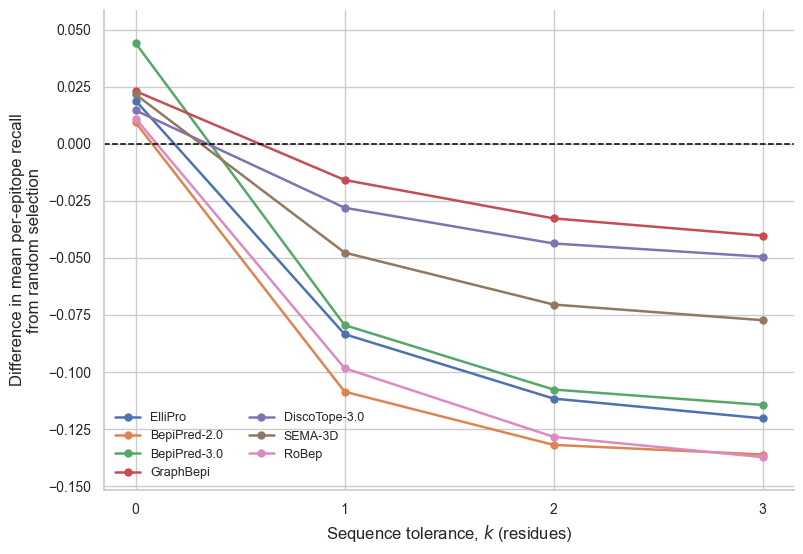

In [16]:
def random_matched_pred(res_df, rng):
    # For each predictor and antigen, randomly select the same number of residues
    # as the number of experimentally annotated epitope residues.
    df = res_df.copy()
    df["y_pred_random"] = 0

    for _, sub in df.groupby(["model", "uniprot"]):
        n = int(sub["y_true"].sum())

        if n > 0:
            pick = rng.choice(
                sub.index.values,
                size=min(n, len(sub)),
                replace=False
            )
            df.loc[pick, "y_pred_random"] = 1

    return df


# ---------------------------------------------------------
# Generate random-selection baseline
# ---------------------------------------------------------

random_rows = []

for b in range(N_PERM):
    rng_b = np.random.default_rng(1000 + b)
    rnd = random_matched_pred(res_fair, rng_b)

    for k in K_VALUES:
        t = tolerant_epitope_recall(
            rnd,
            epitopes_fair,
            COORDS,
            "y_pred_random",
            k,
            D_ANGSTROM
        )

        g = t.groupby("model")["recall"].mean()

        for m in MODEL_LIST:
            random_rows.append({
                "perm": b,
                "model": m,
                "k": k,
                "recall": g[m]
            })


random_df = pd.DataFrame(random_rows)

random_stats = (
    random_df
    .groupby(["model", "k"])["recall"]
    .agg(random_mean="mean", random_sd="std")
    .reset_index()
)

actual = (
    sweep
    .groupby(["model", "k"])["recall"]
    .mean()
    .reset_index()
    .rename(columns={"recall": "observed"})
)

comp = actual.merge(
    random_stats,
    on=["model", "k"]
)

comp["difference_from_random"] = (
    comp["observed"] - comp["random_mean"]
)

# Retain only if needed for supplementary analyses
comp["z"] = (
    (comp["observed"] - comp["random_mean"]) /
    comp["random_sd"].replace(0, np.nan)
)


# ---------------------------------------------------------
# Clean predictor names
# ---------------------------------------------------------

model_names = {
    "ElliPro": "ElliPro",
    "BepiPred2.0": "BepiPred-2.0",
    "BepiPred": "BepiPred-3.0",
    "GraphBepi": "GraphBepi",
    "DiscoTope": "DiscoTope-3.0",
    "SEMAi": "SEMA-3D",
    "RoBep": "RoBep"
}

predictor_order = [
    "ElliPro",
    "BepiPred2.0",
    "BepiPred",
    "GraphBepi",
    "DiscoTope",
    "SEMAi",
    "RoBep"
]


# ---------------------------------------------------------
# Print clean numerical summary
# ---------------------------------------------------------

summary = comp.copy()
summary["Predictor"] = summary["model"].replace(model_names)

summary = summary[
    [
        "Predictor",
        "k",
        "observed",
        "random_mean",
        "difference_from_random"
    ]
].rename(columns={
    "k": "Sequence tolerance",
    "observed": "Observed recall",
    "random_mean": "Random-selection recall",
    "difference_from_random": "Observed − random"
})

print(
    summary
    .sort_values(["Sequence tolerance", "Predictor"])
    .round(3)
    .to_string(index=False)
)


# ---------------------------------------------------------
# Publication-style figure
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(8.2, 5.7))

for model in predictor_order:
    s = (
        comp[comp["model"] == model]
        .sort_values("k")
    )

    ax.plot(
        s["k"],
        s["difference_from_random"],
        marker="o",
        markersize=5,
        linewidth=1.8,
        label=model_names[model]
    )

# Reference: observed recovery = random-selection recovery
ax.axhline(
    0,
    linestyle="--",
    linewidth=1.1,
    color="black"
)

ax.set_xlabel(r"Sequence tolerance, $k$ (residues)")
ax.set_ylabel(
    "Difference in mean per-epitope recall\nfrom random selection"
)

ax.set_xticks(K_VALUES)

# Keep a little space around the data
ymin = comp["difference_from_random"].min()
ymax = comp["difference_from_random"].max()
padding = (ymax - ymin) * 0.08

ax.set_ylim(
    ymin - padding,
    ymax + padding
)

# Clean publication styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.tick_params(
    axis="both",
    labelsize=10
)

ax.legend(
    frameon=False,
    fontsize=9,
    loc="lower left",
    ncol=2
)

fig.tight_layout()

fig.savefig(
    "linear_epitope_recovery_vs_random.png",
    dpi=600,
    bbox_inches="tight"
)

fig.savefig(
    "linear_epitope_recovery_vs_random.pdf",
    bbox_inches="tight"
)

plt.show()

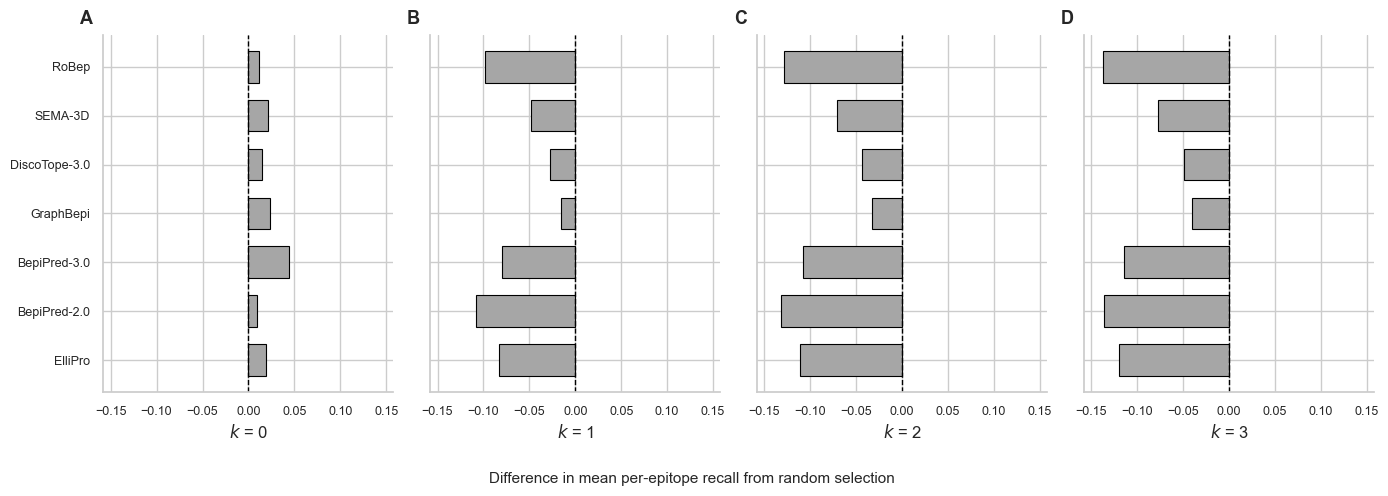

In [18]:
import matplotlib.pyplot as plt
import numpy as np

model_names = {
    "ElliPro": "ElliPro",
    "BepiPred2.0": "BepiPred-2.0",
    "BepiPred": "BepiPred-3.0",
    "GraphBepi": "GraphBepi",
    "DiscoTope": "DiscoTope-3.0",
    "SEMAi": "SEMA-3D",
    "RoBep": "RoBep"
}

predictor_order_raw = [
    "ElliPro",
    "BepiPred2.0",
    "BepiPred",
    "GraphBepi",
    "DiscoTope",
    "SEMAi",
    "RoBep"
]

# Create clean difference column if not already present
plot_comp = comp.copy()

if "difference_from_random" not in plot_comp.columns:
    if "actual" in plot_comp.columns:
        plot_comp["difference_from_random"] = (
            plot_comp["actual"] - plot_comp["null_mean"]
        )
    else:
        plot_comp["difference_from_random"] = (
            plot_comp["observed"] - plot_comp["random_mean"]
        )

plot_comp["Predictor"] = plot_comp["model"].replace(model_names)

# Use the same x-axis limits for all four panels
max_abs = np.abs(plot_comp["difference_from_random"]).max()
xlim = max_abs * 1.15

fig, axes = plt.subplots(
    1, 4,
    figsize=(14, 5),
    sharex=True,
    sharey=True
)

for ax, k in zip(axes, K_VALUES):

    sub = (
        plot_comp[plot_comp["k"] == k]
        .set_index("model")
        .reindex(predictor_order_raw)
        .reset_index()
    )

    values = sub["difference_from_random"].values
    labels = [model_names[m] for m in predictor_order_raw]

    y = np.arange(len(labels))

    ax.barh(
        y,
        values,
        facecolor="0.65",
        edgecolor="black",
        linewidth=0.8,
        height=0.65
    )

    # Zero = same mean recovery as random selection
    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=1
    )

    ax.set_yticks(y)
    ax.set_yticklabels(labels)
    ax.invert_yaxis()

    ax.set_xlim(-xlim, xlim)
    ax.set_xlabel(f"$k$ = {k}")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(axis="both", labelsize=9)

# Common y-axis label not needed because predictor names identify rows
# Common x-axis label across whole figure
fig.supxlabel(
    "Difference in mean per-epitope recall from random selection",
    fontsize=11
)

# Panel labels
for ax, label in zip(axes, ["A", "B", "C", "D"]):
    ax.text(
        -0.08,
        1.03,
        label,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    "linear_epitope_recovery_all_tolerances.png",
    dpi=600,
    bbox_inches="tight"
)

plt.savefig(
    "linear_epitope_recovery_all_tolerances.pdf",
    bbox_inches="tight"
)

plt.show()

In [11]:
def protein_pr(res_df, pred_col):
    rows = []
    for (m, uni), sub in res_df.groupby(["model", "uniprot"]):
        ap = int((sub["y_true"] == 1).sum())
        if ap == 0:
            continue
        pp = int((sub[pred_col] == 1).sum())
        tp = int(((sub[pred_col] == 1) & (sub["y_true"] == 1)).sum())
        prec = tp / pp if pp else 0.0
        rec = tp / ap
        f1 = (2 * prec * rec / (prec + rec)) if (prec + rec) else 0.0
        rows.append({"model": m, "uniprot": uni, "precision": prec, "recall": rec, "f1": f1})
    return pd.DataFrame(rows)

prot_native = protein_pr(res_fair, "y_pred")
prot_matched = protein_pr(res_fair, "y_pred_matched")

prot_prec_summary = (prot_native.groupby("model")
                     .agg(mean_precision_native=("precision", "mean"),
                          mean_recall_native=("recall", "mean"),
                          mean_f1_native=("f1", "mean")).reset_index())
print("per-protein (native cutoff):")
print(prot_prec_summary.round(3).to_string(index=False))


per-protein (native cutoff):
      model  mean_precision_native  mean_recall_native  mean_f1_native
   BepiPred                  0.194               0.200           0.154
BepiPred2.0                  0.212               0.717           0.268
  DiscoTope                  0.234               0.225           0.171
    ElliPro                  0.217               0.496           0.236
  GraphBepi                  0.223               0.278           0.171
      RoBep                  0.229               0.046           0.062
      SEMAi                  0.217               0.575           0.255


## 8. Detection-rate sweep D(τ)

D(τ) = fraction of epitopes with recall ≥ τ. The area under D(τ) equals the mean per-epitope
recall (the identity is checked below), so the sweep is the threshold-free summary and the 25%
rule is just one point on it.

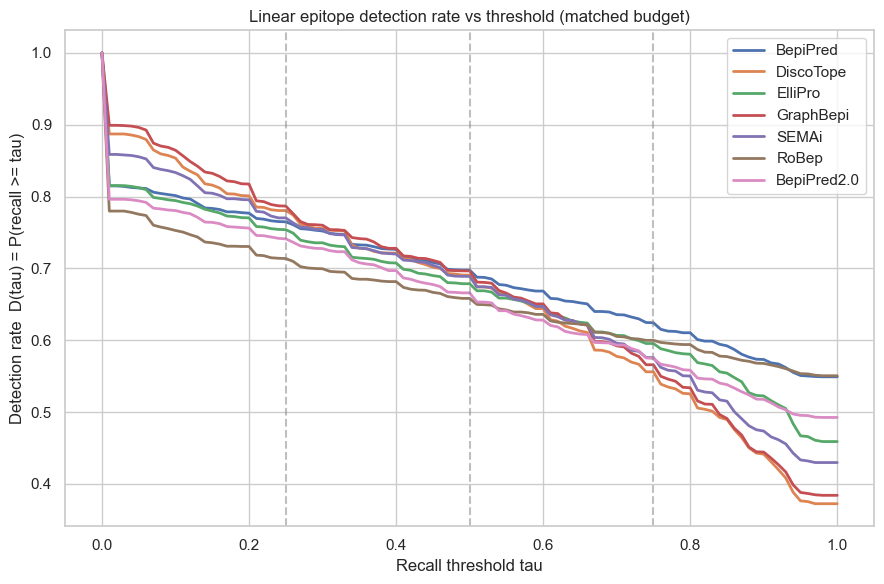

mean recall vs area under D(tau):
  BepiPred   mean_recall=0.689  area_under_D=0.691
  DiscoTope  mean_recall=0.660  area_under_D=0.661
  ElliPro    mean_recall=0.665  area_under_D=0.666
  GraphBepi  mean_recall=0.668  area_under_D=0.669
  SEMAi      mean_recall=0.666  area_under_D=0.667
  RoBep      mean_recall=0.657  area_under_D=0.658
  BepiPred2.0 mean_recall=0.654  area_under_D=0.655


In [12]:
def detection_curve(rec_df, recall_col, taus):
    rows = []
    for m, sub in rec_df.groupby("model"):
        r = sub[recall_col].dropna().values
        for t in taus:
            rows.append({"model": m, "tau": t, "detection_rate": float((r >= t).mean())})
    return pd.DataFrame(rows)

curve = detection_curve(ep_recall, "recall_matched", TAUS)

plt.figure(figsize=(9, 6))
for m in MODEL_LIST:
    s = curve[curve.model == m]
    plt.plot(s["tau"], s["detection_rate"], lw=2, label=m)
for p in DET_POINTS:
    plt.axvline(p, ls="--", color="gray", alpha=0.5)
plt.xlabel("Recall threshold tau")
plt.ylabel("Detection rate  D(tau) = P(recall >= tau)")
plt.title("Linear epitope detection rate vs threshold (matched budget)")
plt.legend()
plt.tight_layout()
plt.show()

# identity check: area under D(tau) == mean recall
print("mean recall vs area under D(tau):")
for m in MODEL_LIST:
    mean_r = ep_recall.loc[ep_recall.model == m, "recall_matched"].mean()
    s = curve[curve.model == m].sort_values("tau")
    _trap = getattr(np, "trapezoid", getattr(np, "trapz", None))
    area = _trap(s["detection_rate"].values, s["tau"].values)
    print(f"  {m:10s} mean_recall={mean_r:.3f}  area_under_D={area:.3f}")


/var/folders/cp/75kstzzx29xbkmz2xf3rg4xm0000gn/T/ipykernel_10071/300563095.py:211: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


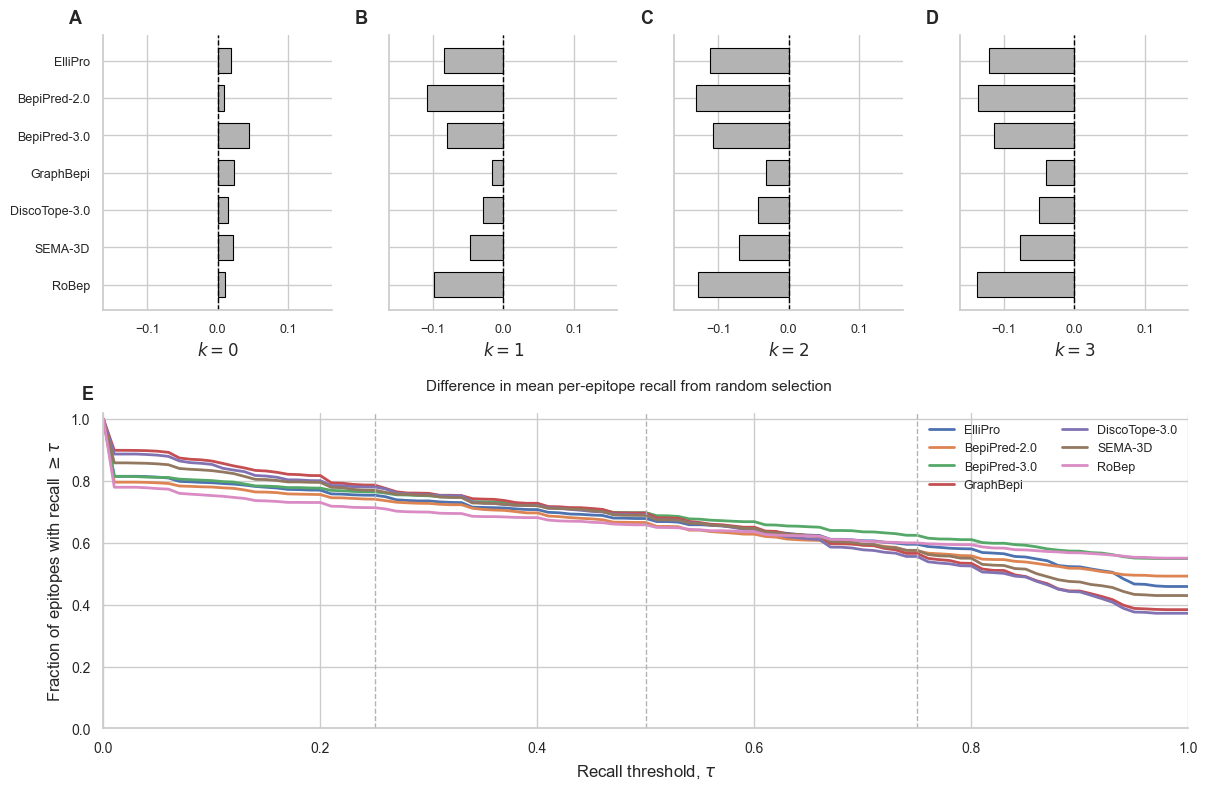

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec

# ---------------------------------------------------------
# Clean predictor names and order
# ---------------------------------------------------------
model_names = {
    "ElliPro": "ElliPro",
    "BepiPred2.0": "BepiPred-2.0",
    "BepiPred": "BepiPred-3.0",
    "GraphBepi": "GraphBepi",
    "DiscoTope": "DiscoTope-3.0",
    "SEMAi": "SEMA-3D",
    "RoBep": "RoBep"
}

predictor_order_raw = [
    "ElliPro",
    "BepiPred2.0",
    "BepiPred",
    "GraphBepi",
    "DiscoTope",
    "SEMAi",
    "RoBep"
]

predictor_order_clean = [model_names[m] for m in predictor_order_raw]

# Consistent colors for detection-rate curves
default_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
model_colors = {m: default_colors[i % len(default_colors)] for i, m in enumerate(predictor_order_raw)}

# ---------------------------------------------------------
# Build random-selection comparison table if needed
# ---------------------------------------------------------
def random_matched_pred(res_df, rng):
    df = res_df.copy()
    df["y_pred_random"] = 0

    for _, sub in df.groupby(["model", "uniprot"]):
        n = int(sub["y_true"].sum())
        if n > 0:
            pick = rng.choice(sub.index.values, size=min(n, len(sub)), replace=False)
            df.loc[pick, "y_pred_random"] = 1

    return df

null_rows = []

for b in range(N_PERM):
    rng_b = np.random.default_rng(1000 + b)
    rnd = random_matched_pred(res_fair, rng_b)

    for k in K_VALUES:
        t = tolerant_epitope_recall(rnd, epitopes_fair, COORDS, "y_pred_random", k, D_ANGSTROM)
        g = t.groupby("model")["recall"].mean()

        for m in MODEL_LIST:
            null_rows.append({
                "perm": b,
                "model": m,
                "k": k,
                "recall": g[m]
            })

null_df = pd.DataFrame(null_rows)

null_stats = (
    null_df.groupby(["model", "k"])["recall"]
    .agg(random_mean="mean", random_sd="std")
    .reset_index()
)

actual = (
    sweep.groupby(["model", "k"])["recall"]
    .mean()
    .reset_index()
    .rename(columns={"recall": "observed"})
)

comp = actual.merge(null_stats, on=["model", "k"])
comp["difference_from_random"] = comp["observed"] - comp["random_mean"]
comp["Predictor"] = comp["model"].replace(model_names)

# ---------------------------------------------------------
# Detection-rate curve
# ---------------------------------------------------------
def detection_curve(rec_df, recall_col, taus):
    rows = []
    for m, sub in rec_df.groupby("model"):
        r = sub[recall_col].dropna().values
        for t in taus:
            rows.append({
                "model": m,
                "tau": t,
                "detection_rate": float((r >= t).mean())
            })
    return pd.DataFrame(rows)

curve = detection_curve(ep_recall, "recall_matched", TAUS)

# ---------------------------------------------------------
# Figure layout: A-D on top, E spanning full width below
# ---------------------------------------------------------
fig = plt.figure(figsize=(14, 9))
gs = gridspec.GridSpec(
    2, 4,
    height_ratios=[1, 1.15],
    hspace=0.35,
    wspace=0.25
)

axes_top = [fig.add_subplot(gs[0, i]) for i in range(4)]
ax_det = fig.add_subplot(gs[1, :])

# Common x-axis limits for bar panels
max_abs = np.abs(comp["difference_from_random"]).max()
xlim = max_abs * 1.18

panel_labels = ["A", "B", "C", "D"]

for ax, k, panel in zip(axes_top, K_VALUES, panel_labels):
    sub = (
        comp[comp["k"] == k]
        .set_index("model")
        .reindex(predictor_order_raw)
        .reset_index()
    )

    y = np.arange(len(predictor_order_raw))
    values = sub["difference_from_random"].values
    labels = [model_names[m] for m in predictor_order_raw]

    ax.barh(
        y,
        values,
        height=0.68,
        facecolor="0.70",
        edgecolor="black",
        linewidth=0.8
    )

    ax.axvline(0, linestyle="--", color="black", linewidth=1)

    ax.set_yticks(y)
    if ax is axes_top[0]:
        ax.set_yticklabels(labels)
    else:
        ax.set_yticklabels([])

    ax.invert_yaxis()
    ax.set_xlim(-xlim, xlim)
    ax.set_xlabel(rf"$k = {k}$")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=9)

    ax.text(
        -0.15, 1.03, panel,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="bottom"
    )

# Shared label for top row
fig.text(
    0.5, 0.49,
    "Difference in mean per-epitope recall from random selection",
    ha="center",
    va="center",
    fontsize=11
)

# ---------------------------------------------------------
# Panel E: detection-rate curve spanning full width
# ---------------------------------------------------------
for m in predictor_order_raw:
    s = curve[curve["model"] == m].sort_values("tau")
    ax_det.plot(
        s["tau"],
        s["detection_rate"],
        linewidth=2,
        color=model_colors[m],
        label=model_names[m]
    )

for p in DET_POINTS:
    ax_det.axvline(p, linestyle="--", color="0.7", linewidth=1)

ax_det.set_xlabel(r"Recall threshold, $\tau$")
ax_det.set_ylabel(r"Fraction of epitopes with recall $\geq \tau$")
ax_det.set_xlim(0, 1)
ax_det.set_ylim(0, 1.02)
ax_det.spines["top"].set_visible(False)
ax_det.spines["right"].set_visible(False)
ax_det.tick_params(axis="both", labelsize=10)
ax_det.legend(frameon=False, fontsize=9, loc="upper right", ncol=2)

ax_det.text(
    -0.02, 1.03, "E",
    transform=ax_det.transAxes,
    fontsize=13,
    fontweight="bold",
    va="bottom"
)

plt.tight_layout()

plt.savefig("linear_epitope_recovery_combined.png", dpi=600, bbox_inches="tight")
plt.savefig("linear_epitope_recovery_combined.pdf", bbox_inches="tight")

plt.show()

In [13]:
def mean_recall_by_model(rec_df, col):
    return rec_df.groupby("model")[col].mean()

det_at = {}
for p in DET_POINTS:
    det_at[p] = (ep_recall.dropna(subset=["recall_matched"])
                 .groupby("model")["recall_matched"]
                 .apply(lambda r: (r >= p).mean()))

summary = pd.DataFrame({
    "n_epitopes": ep_recall.dropna(subset=["recall_matched"]).groupby("model").size(),
    "mean_recall_native": mean_recall_by_model(ep_recall, "recall_native"),
    "mean_recall_matched": mean_recall_by_model(ep_recall, "recall_matched"),
})
for p in DET_POINTS:
    summary[f"det@{p:.2f}"] = det_at[p]
summary = summary.merge(
    prot_prec_summary.set_index("model")[["mean_precision_native", "mean_f1_native"]],
    left_index=True, right_index=True)
summary = summary.reset_index().rename(columns={"index": "model"})

print("LINEAR REGIONAL SUMMARY (matched budget unless noted)")
print(summary.round(3).to_string(index=False))
print("\nRanking by mean per-epitope recall (matched budget):")
print(summary.sort_values("mean_recall_matched", ascending=False)
      [["model", "mean_recall_matched", "mean_precision_native"]].round(3).to_string(index=False))


LINEAR REGIONAL SUMMARY (matched budget unless noted)
      model  n_epitopes  mean_recall_native  mean_recall_matched  det@0.25  det@0.50  det@0.75  mean_precision_native  mean_f1_native
   BepiPred        2739               0.328                0.689     0.765     0.698     0.624                  0.194           0.154
BepiPred2.0        2739               0.757                0.654     0.741     0.666     0.575                  0.212           0.268
  DiscoTope        2739               0.279                0.660     0.781     0.691     0.556                  0.234           0.171
    ElliPro        2739               0.529                0.665     0.754     0.679     0.595                  0.217           0.236
  GraphBepi        2739               0.257                0.668     0.787     0.697     0.566                  0.223           0.171
      RoBep        2739               0.077                0.657     0.714     0.658     0.600                  0.229           0.062
      SE

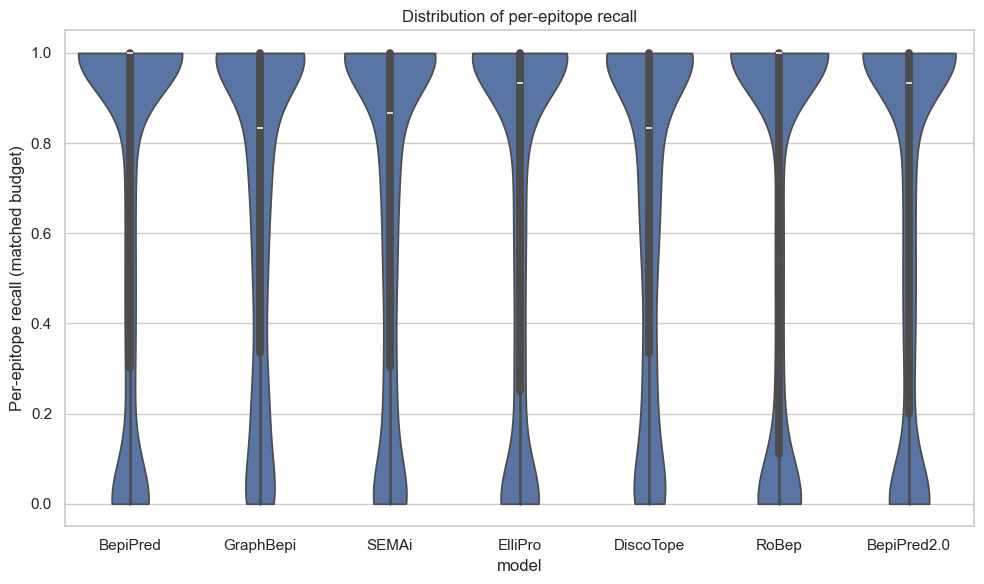

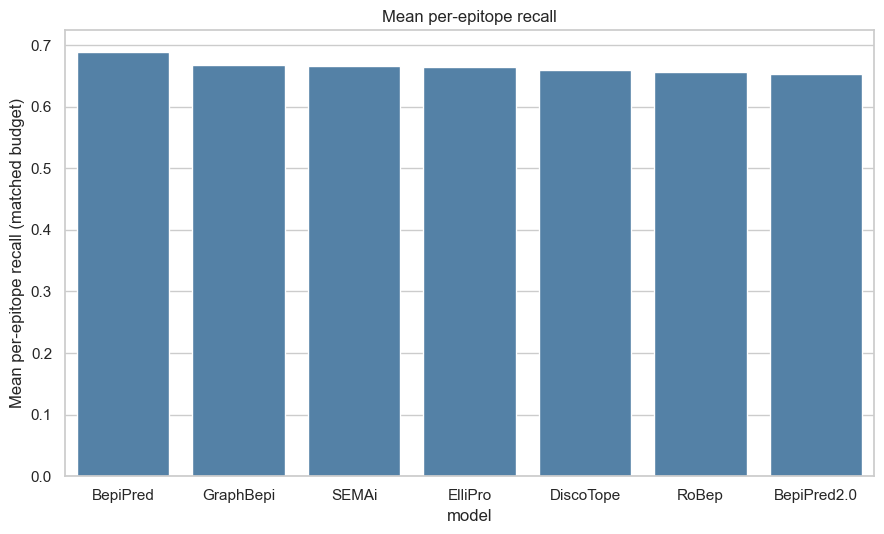

In [14]:
plt.figure(figsize=(10, 6))
order = summary.sort_values("mean_recall_matched", ascending=False)["model"]
sns.violinplot(data=ep_recall.dropna(subset=["recall_matched"]),
               x="model", y="recall_matched", order=order, cut=0)
plt.ylabel("Per-epitope recall (matched budget)")
plt.title("Distribution of per-epitope recall")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5.5))
sns.barplot(data=summary, x="model", y="mean_recall_matched",
            order=order, color="steelblue")
plt.ylabel("Mean per-epitope recall (matched budget)")
plt.title("Mean per-epitope recall")
plt.tight_layout()
plt.show()
